In [1]:
import numpy as np
import matplotlib.pyplot as plt
from h5py import File
from pathlib import Path

from cdmprof import fit_nfw

In [15]:
# Load particle data
data_path = Path("../data/tng_particles/particles_033.hdf5")

with File(data_path, 'r') as f:
    radii = f['radii'][:]
    positions = f['positions'][:]
    halo_ids = f['halo_id'][:]
    offsets = f['offsets'][:]
    M200c = f['M200c'][:]
    R200c = f['R200c'][:]

n_halos = len(halo_ids)
id_to_idx = {hid: i for i, hid in enumerate(halo_ids)}

print(f"Loaded {n_halos} halos")
print(f"Total particles: {len(radii):,}")
print(f"Mass range: {M200c.min():.2e} - {M200c.max():.2e} Msun/h")

Loaded 61 halos
Total particles: 610,000
Mass range: 1.00e+12 - 4.47e+13 Msun/h


In [20]:
def get_halo_radii(idx):
    """Get radii for halo at index idx."""
    return radii[offsets[idx]:offsets[idx + 1]]


def compute_outer_slope(r_norm, r_min_frac=0.7, r_max_frac=1.0, n_bins=10):
    """
    Compute the slope of log(density) vs log(r) in the outer region.

    Returns (slope, slope_err) - slope should be negative for well-behaved halo.
    """
    # Select particles in the outer region
    mask = (r_norm >= r_min_frac) & (r_norm <= r_max_frac)
    if mask.sum() < 2 * n_bins:
        return np.nan, np.nan

    r_outer = r_norm[mask]
    bin_edges = np.linspace(r_min_frac, r_max_frac, n_bins + 1)
    counts, _ = np.histogram(r_outer, bins=bin_edges)

    # Compute density (counts / shell volume)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    shell_volumes = bin_edges[1:]**3 - bin_edges[:-1]**3
    density = counts / shell_volumes

    # Only fit bins with non-zero counts
    valid = density > 0
    if valid.sum() < 3:
        return np.nan, np.nan

    # Fit line to log(density) vs log(r)
    x = np.log(bin_centers[valid])
    y = np.log(density[valid])
    n = len(x)

    # Linear regression
    x_mean = x.mean()
    y_mean = y.mean()
    ss_xx = ((x - x_mean)**2).sum()
    ss_xy = ((x - x_mean) * (y - y_mean)).sum()

    slope = ss_xy / ss_xx
    intercept = y_mean - slope * x_mean

    # Residuals and standard error of slope
    y_pred = slope * x + intercept
    residuals = y - y_pred
    mse = (residuals**2).sum() / (n - 2)  # degrees of freedom = n - 2
    slope_err = np.sqrt(mse / ss_xx)

    return slope, slope_err


def nfw_cdf(r, rs):
    """NFW cumulative distribution function (unnormalized)."""
    x = r / rs
    return np.log(1 + x) + 1 / (1 + x)


def sample_uniform_in_log_mass(n_samples, n_bins=12, seed=42):
    """Sample halos uniformly in log mass (counteracts HMF bias)."""
    rng = np.random.default_rng(seed)

    log_mass = np.log10(M200c)
    bin_edges = np.linspace(log_mass.min(), log_mass.max(), n_bins + 1)

    # Assign each halo to a bin
    bin_idx = np.digitize(log_mass, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    # Sample equally from each bin
    samples_per_bin = max(1, n_samples // n_bins)
    selected = []

    for b in range(n_bins):
        in_bin = np.where(bin_idx == b)[0]
        if len(in_bin) > 0:
            n_take = min(samples_per_bin, len(in_bin))
            selected.extend(rng.choice(in_bin, size=n_take, replace=False))

    # Sort by mass for nice ordering in plots
    selected = np.array(selected)
    return selected[np.argsort(M200c[selected])]


def plot_halo_grid(indices, nrows=4, ncols=3, n_bins=50):
    """Plot a grid of halo radii histograms with NFW fit and outer slope."""
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i >= len(indices):
            ax.axis('off')
            continue

        idx = indices[i]
        r = get_halo_radii(idx)
        r_norm = r / R200c[idx]

        # Compute outer slope
        slope, slope_err = compute_outer_slope(r_norm)

        # Plot histogram
        bin_edges = np.linspace(r_norm.min(), r_norm.max(), n_bins + 1)
        counts, _ = np.histogram(r_norm, bins=bin_edges)
        ax.hist(r_norm, bins=bin_edges, color='black', histtype='step')
        ax.axvline(0.6, color='red', ls='--', lw=0.8, alpha=0.7)

        # Fit NFW
        result = fit_nfw(r_norm, nbin=n_bins, seed=42)
        rs = result['rs']

        # Compute expected counts from NFW fit
        if np.isfinite(rs) and rs > 0:
            # Expected count in each bin from NFW CDF
            cdf_edges = nfw_cdf(bin_edges, rs)
            cdf_norm = cdf_edges - cdf_edges[0]  # Start from 0
            cdf_norm = cdf_norm / cdf_norm[-1]   # Normalize to 1
            expected_counts = len(r_norm) * np.diff(cdf_norm)

            # Plot at bin centers
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            ax.plot(bin_centers, expected_counts, 'C0-', lw=1.5)
        ax.set_xlim(0, 1)
        ax.set_xlabel(r'$r / R_{200c}$')
        ax.set_ylabel('Count')
        ax.set_title(f"ID={halo_ids[idx]}, log M={np.log10(M200c[idx]):.2f}, "
                     r"$\gamma_{\rm out}$" + f"={slope:.1f}±{slope_err:.1f}", fontsize=10)

    plt.tight_layout()
    return fig

Selected 13 halos spanning log M = 12.00 to 13.65


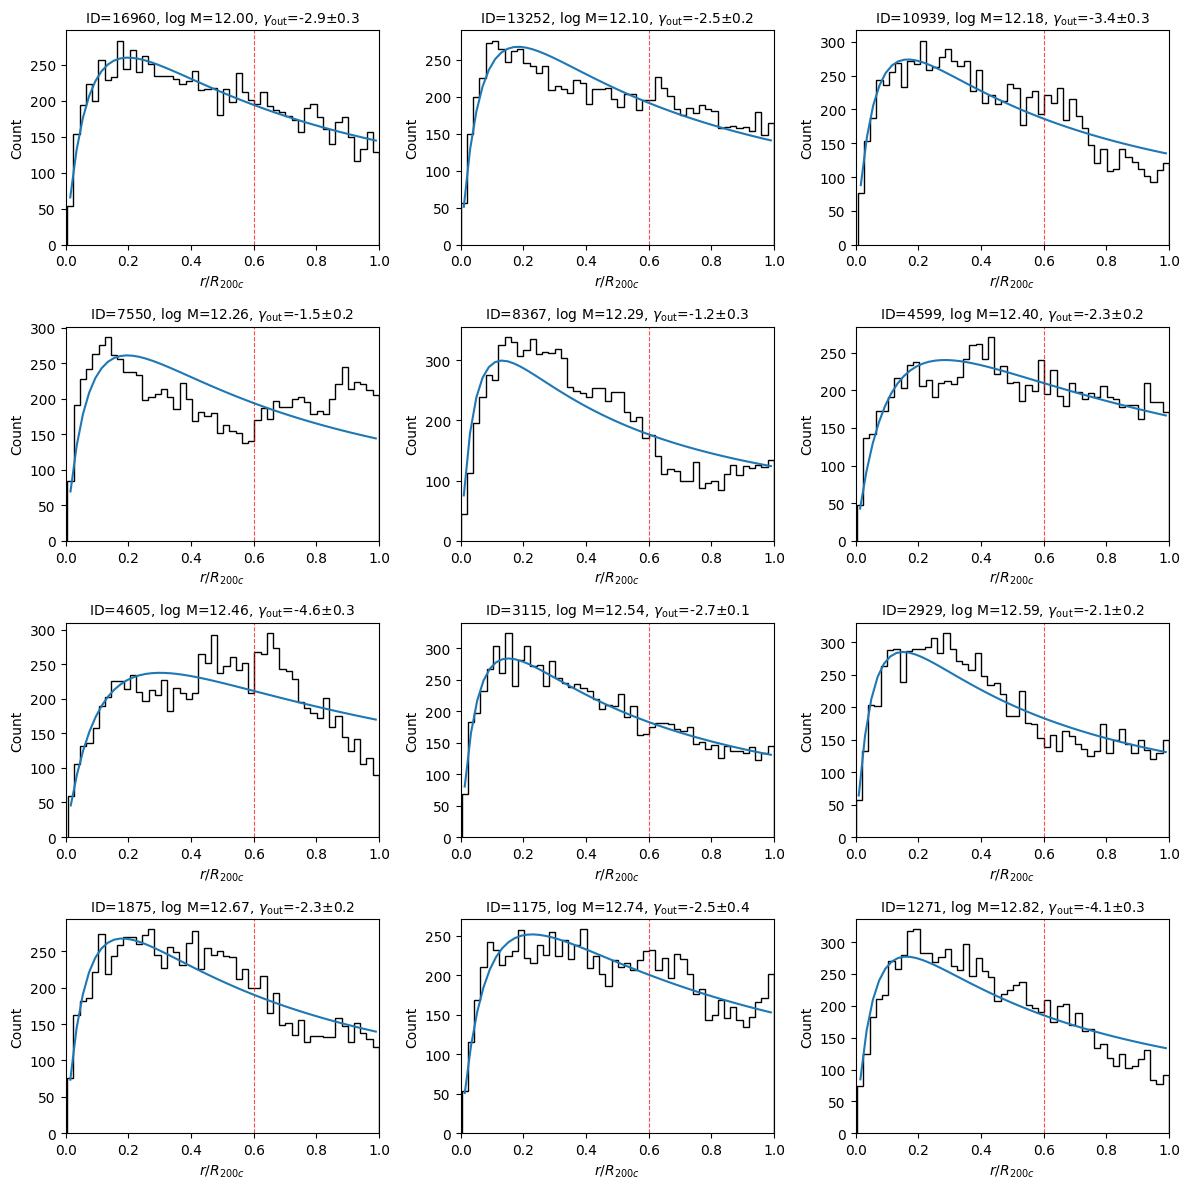

In [22]:
# Sample uniformly in log mass
selected = sample_uniform_in_log_mass(n_samples=12, n_bins=24, seed=None)
print(f"Selected {len(selected)} halos spanning log M = {np.log10(M200c[selected].min()):.2f} to {np.log10(M200c[selected].max()):.2f}")

# First 12 halos (low to mid mass)
fig = plot_halo_grid(selected)
fig.savefig("/Users/rstiskalek/Downloads/halo_grid.png", dpi=300)
plt.show()

In [5]:
def get_halo_positions(halo_id):
    """Get positions for halo by ID."""
    if halo_id not in id_to_idx:
        raise ValueError(f"Halo {halo_id} not found")
    idx = id_to_idx[halo_id]
    return positions[offsets[idx]:offsets[idx + 1]]


def plot_projections(halo_id, s=0.1, alpha=0.5):
    """Plot x-y, x-z, y-z projections for a halo."""
    idx = id_to_idx[halo_id]
    pos = get_halo_positions(halo_id)
    r200 = R200c[idx]
    mass = M200c[idx]
    
    # Normalize by R200c
    pos_norm = pos / r200
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    projections = [(0, 1, 'x', 'y'), (0, 2, 'x', 'z'), (1, 2, 'y', 'z')]
    
    for ax, (i, j, xi, xj) in zip(axes, projections):
        ax.scatter(pos_norm[:, i], pos_norm[:, j], s=s, alpha=alpha, c='black')
        ax.set_xlabel(f'${xi} / R_{{200c}}$')
        ax.set_ylabel(f'${xj} / R_{{200c}}$')
        ax.set_aspect('equal')
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        
        # Draw R200c circle
        theta = np.linspace(0, 2*np.pi, 100)
        ax.plot(np.cos(theta), np.sin(theta), 'r--', lw=1, label=r'$R_{200c}$')
    
    axes[0].legend(loc='upper right')
    fig.suptitle(f"Halo {halo_id}, log M = {np.log10(mass):.2f}", fontsize=12)
    plt.tight_layout()
    return fig

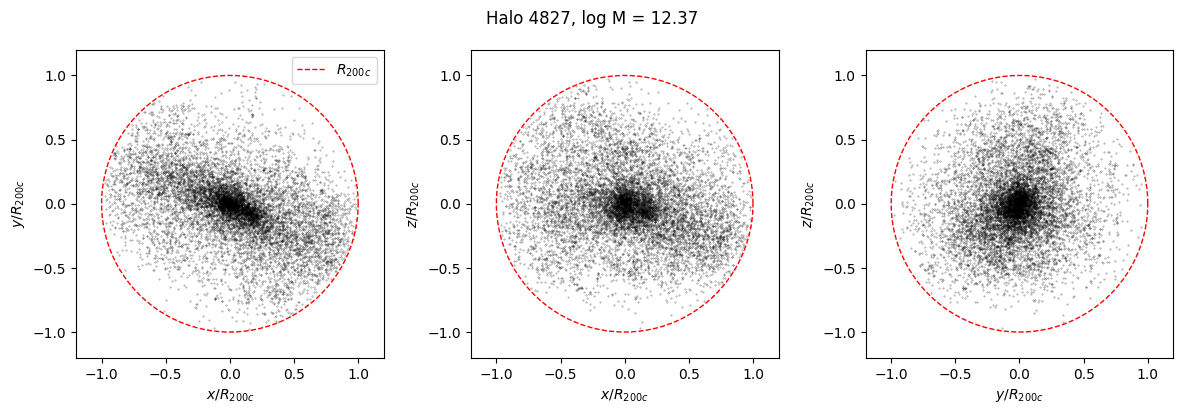

In [19]:
hid = 4827

# Plot projections for a specific halo
plot_projections(hid)
plt.show()